# Decision Trees

A **decision tree** is a non-parametric *discriminative* classifier. In particular, a decision tree is a hierarchical model for supervised learning whereby the local region (in the feature space) is identified in a sequence of recursive splits in a smaller number of steps. 

There are many models to measure the quality of the split. The splitting models for **classification tasks** look at maximize information gain or minimize impurity. The learning algorithm is also known as **CART** which stands for **Classification and Regression Tree**.

The most common impurity criteria for classification are:

1. **Entropy** is an information gain split criterion.

$$I_H = -\sum_{j=1}^c p_j \log_2(p_j)$$

2. **Gini Index** is an impurity split criterion.

$$I_G = 1 - \sum_{j=1}^c p_j^2$$

where $p_i$ is the proportion of samples that belong to class $i$ for a particular node.

3. **Classification Error** is a useful criterion for pruning but not recommended for growing a decision tree, since it is less sensitive to changes in the class probabilities of the nodes.

$$I_E = 1 - \max_{j=1,\dots,c}(p_j)$$

```Scikit-learn``` implements **binary splits** ($D_{\text{left}}$ and $D_{\text{righ}}$) in order to reduce to search space.

Each split uses the feature that maximizes the **information gain**:

$$IG(D_p, f) = I(D_p) - \frac{N_{\text{left}}}{N_p} I(D_{\text{left}}) - \frac{N_{\text{right}}}{N_p} I(D_{\text{right}})$$

where $f$ is the feature to perform the splitting, $D_p$ is the dataset of the parent node, $D_{\text{left}}$ is the dataset of the left child node, $D_{\text{righ}}$ is the dataset of the right child node, and $I(D_j)$ is the impurity measure of the dataset in the $j$-th node.

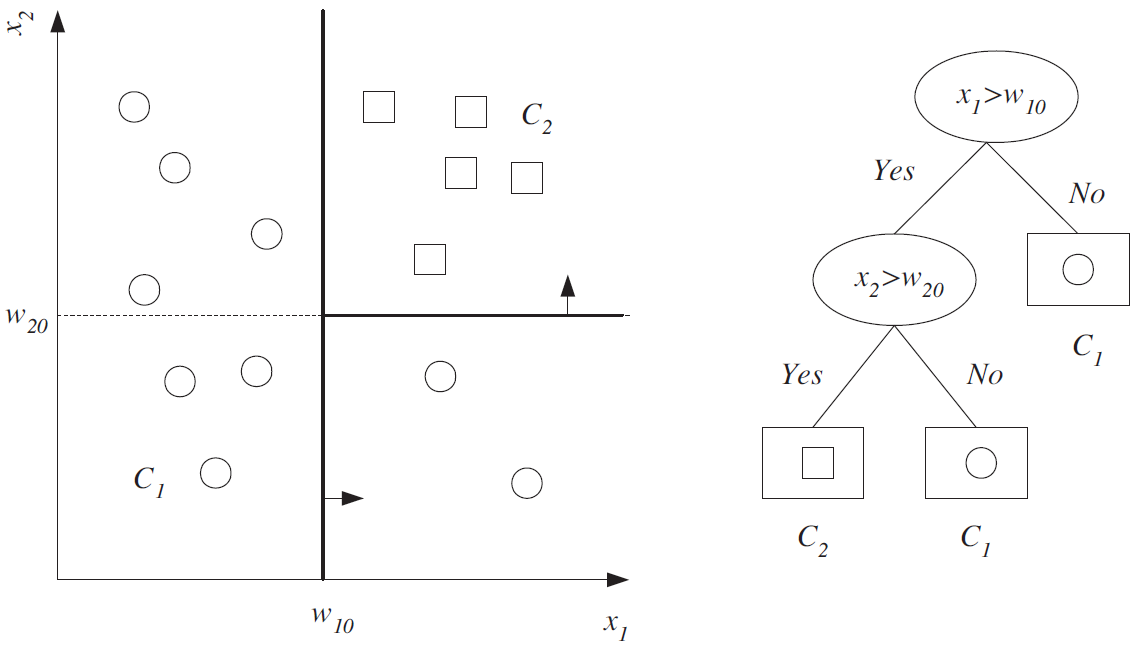

In [1]:
from IPython.display import Image
Image('figures/DecisionTree.png', width=700)

## Observations

* **Interpretatbility**. An advantage of a decision tree is interpretability. The tree can be converted to a set of IF-THEN rules that are easily understandable. For this reason, decision trees are very popular and sometimes preferred over more accurate but less interpretable methods.

* **Overfitting**. Decision trees are prone to overfitting, especially when the tree depth increases. Maximum tree depth occurs when splits are performed until children nodes are *pure* (no misclassifications).

* **Variability**. Small changes in the training dataset may result in completely different decision surfaces (produced by the decision tree).

# Creating a Decision Tree

Consider the following two-dimensional data, which has one of four class labels:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.style.use('bmh')

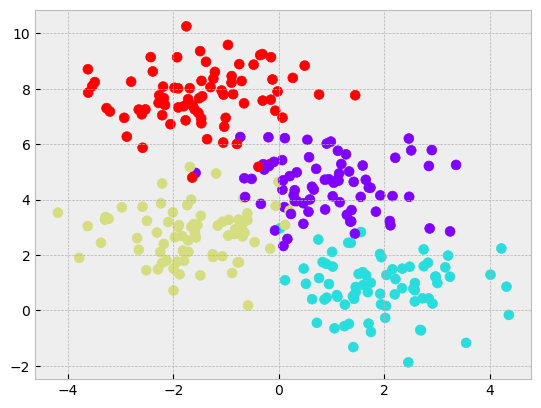

In [3]:
from sklearn.datasets import make_blobs

X, t = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='rainbow');

A simple decision tree built on this data will iteratively split the data along one or the other axis according to some quantitative criterion, and at each level assign the label of the new region according to a majority vote of points within it. This figure presents a visualization of the first four levels of a decision tree classifier for this data:

In [4]:
def visualize_tree(estimator, X, t, boundaries=True,
                   xlim=None, ylim=None, ax=None):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=t, s=30, cmap='viridis',
               clim=(t.min(), t.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()
    
    # fit the estimator
    estimator.fit(X, t)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    n_classes = len(np.unique(t))
    Z = Z.reshape(xx.shape)
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='viridis',zorder=1)

    ax.set(xlim=xlim, ylim=ylim)
    
    # Plot the decision boundaries
    def plot_boundaries(i, xlim, ylim):
        if i >= 0:
            tree = estimator.tree_
        
            if tree.feature[i] == 0:
                ax.plot([tree.threshold[i], tree.threshold[i]], ylim, '-k', zorder=2)
                plot_boundaries(tree.children_left[i],
                                [xlim[0], tree.threshold[i]], ylim)
                plot_boundaries(tree.children_right[i],
                                [tree.threshold[i], xlim[1]], ylim)
        
            elif tree.feature[i] == 1:
                ax.plot(xlim, [tree.threshold[i], tree.threshold[i]], '-k', zorder=2)
                plot_boundaries(tree.children_left[i], xlim,
                                [ylim[0], tree.threshold[i]])
                plot_boundaries(tree.children_right[i], xlim,
                                [tree.threshold[i], ylim[1]])
            
    if boundaries:
        plot_boundaries(0, xlim, ylim)

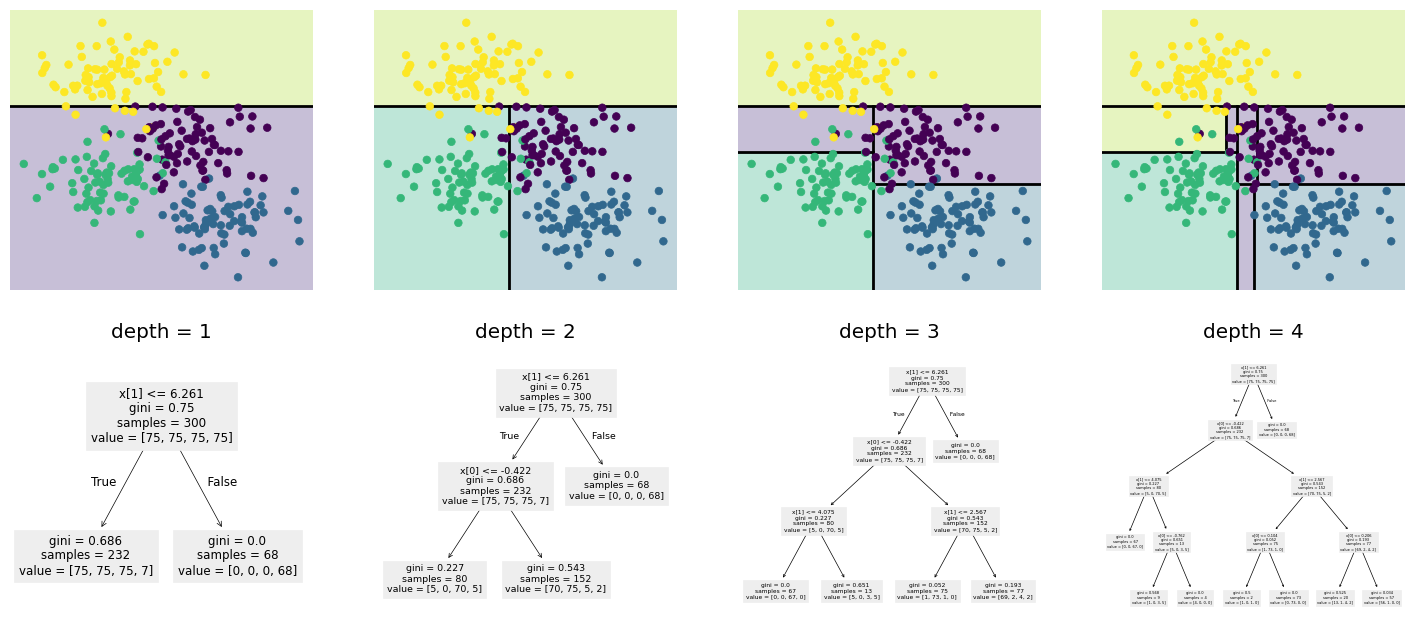

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

plt.figure(figsize=(18, 8))

depth = 5
for depth in range(1, 5):
    model = DecisionTreeClassifier(max_depth=depth)
    plt.subplot(2,4,depth);visualize_tree(model, X, t)
    plt.subplot(2,4,depth+4);tree.plot_tree(model)
    plt.title('depth = {0}'.format(depth))

Notice that after the first split, every point in the upper branch remains unchanged, so there is no need to further subdivide this branch. Except for nodes that contain all of one color, at each level every region is again split along one of the two features.

This process of fitting a decision tree to our data can be done in Scikit-Learn with the ```DecisionTreeClassifier``` estimator:

In [6]:
from sklearn.tree import DecisionTreeClassifier

DecisionTreeClassifier?

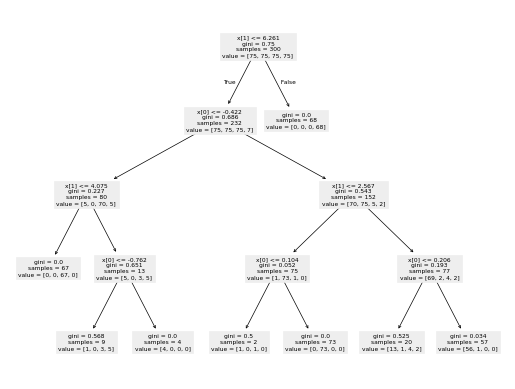

In [7]:
dt = DecisionTreeClassifier(max_depth=4,random_state=0)
dt.fit(X,t)

tree.plot_tree(dt);

---
---
---

# Exercise

Suppose that we have a dataset $\{(\mathbf{x}_i, t_i)\}_{i=1}^N$, where $\mathbf{x}_i \in \mathbb{R}^2$ and $t_i\in\{0,1\}$, that is, we are dealing with a 2-dimensional feature space and 2 classes. Assume that we have 80 samples total in training, where 40 samples are from $C_0$ and 40 samples from $C_1$.

In constructing a tree, we must decide which feature (and at what threshold) should be used to split the parent node.

The figure below illustrates the resulting tree when (A) using feature 1 to split the parent note, and (B) using feature 2 to split the parent node.

1. Which decision tree would you choose?

2. Compute the information gain using all impurity measures.

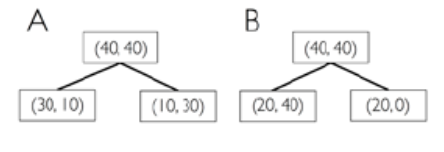

In [8]:
from IPython.display import Image
Image('figures/tree_split_example.png', width=300)

---
---
---

## Visualizing a Decision Tree

Let's write a quick utility function to help us visualize the output of the classifier:

In [10]:
from ipywidgets import interact

def visualize_classifier(model, X, t, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=t, s=30, cmap=cmap,
               clim=(t.min(), t.max()), zorder=3)
    ax.axis('tight')
#     ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # fit the estimator
    model.fit(X, t)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(t))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)
    
def plot_tree_interactive(X, t):
    def interactive_tree(depth=5):
        clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
        visualize_tree(clf, X, t)

    return interact(interactive_tree, depth=[1,2,3,4,5,6,7,8,9,10,20,50])


def randomized_tree_interactive(X, t):
    N = int(0.75 * X.shape[0])
    
    xlim = (X[:, 0].min(), X[:, 0].max())
    ylim = (X[:, 1].min(), X[:, 1].max())
    
    def fit_randomized_tree(random_state=0):
        clf = DecisionTreeClassifier(max_depth=15)
        i = np.arange(len(t))
        rng = np.random.RandomState(random_state)
        rng.shuffle(i)
        visualize_tree(clf, X[i[:N]], t[i[:N]], boundaries=False,
                       xlim=xlim, ylim=ylim)
    
    interact(fit_randomized_tree, random_state=[0, 100]);

Now we can examine what the decision tree classification looks like:

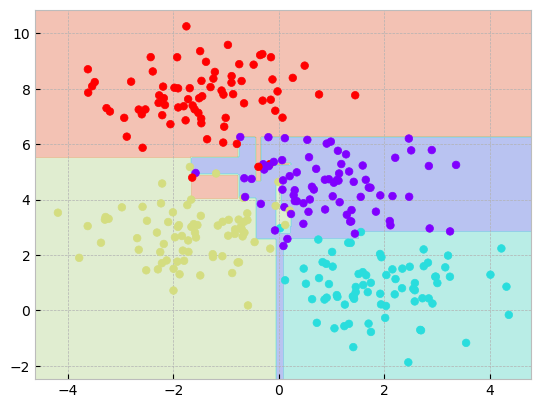

In [11]:
visualize_classifier(DecisionTreeClassifier(), X, t)

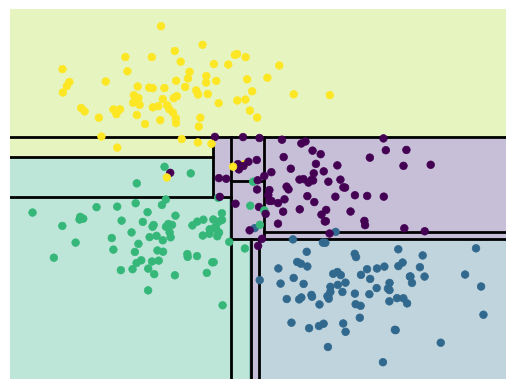

interactive(children=(Dropdown(description='depth', index=4, options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50), …

In [12]:
plot_tree_interactive(X, t);

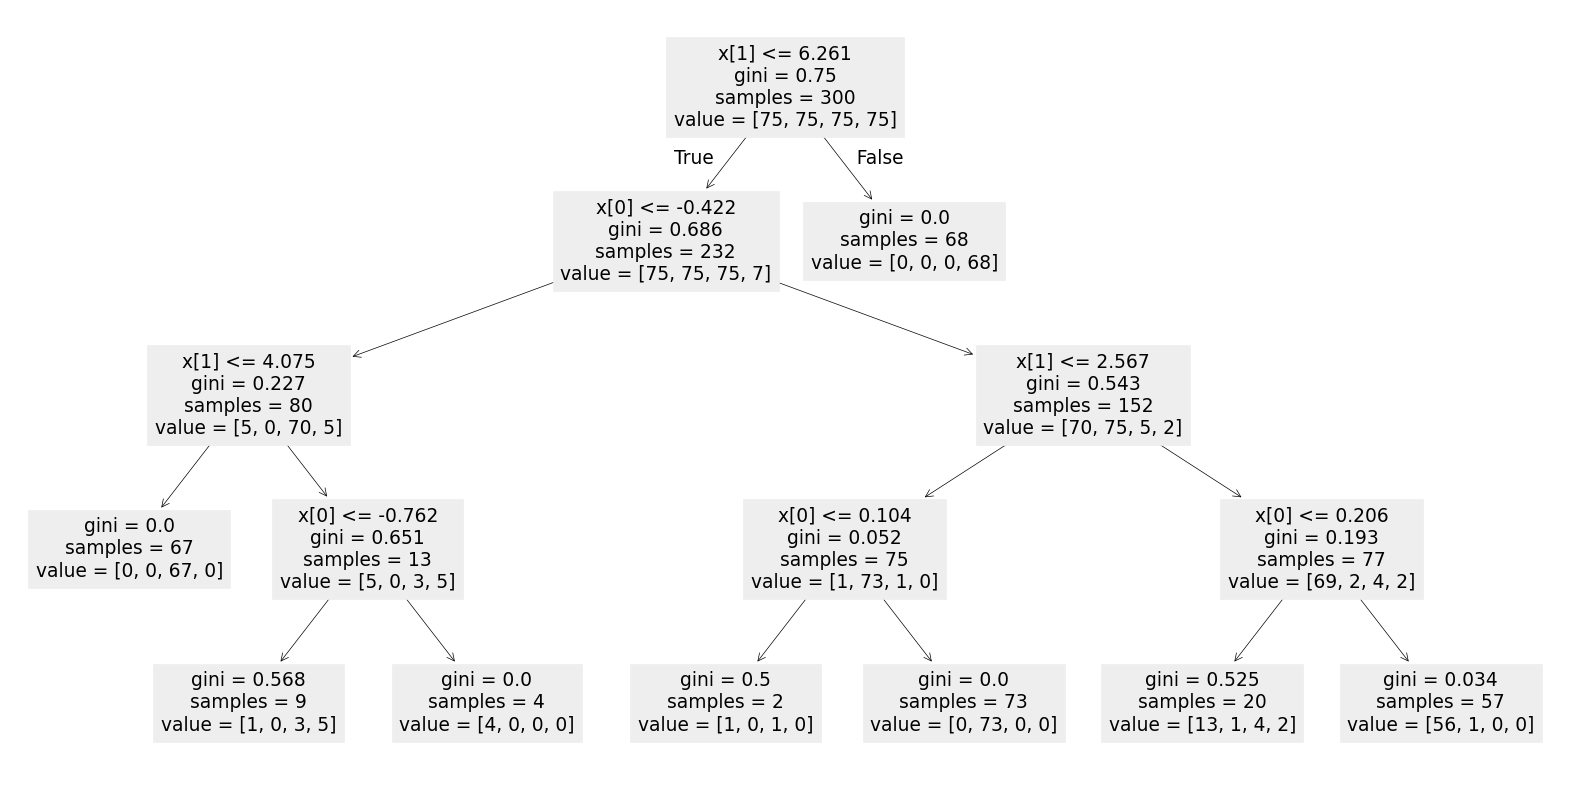

In [13]:
from sklearn.tree import plot_tree

dt = DecisionTreeClassifier(max_depth=4,random_state=0)
dt.fit(X,t)

plt.figure(figsize=(20,10))
plot_tree(dt);

Notice that as the depth increases, we tend to get very strangely shaped classification regions. 

It's clear that this is less a result of the true, intrinsic data distribution, and more a result of the particular sampling or noise properties of the data. That is, this decision tree, even at only five levels deep, is clearly overfitting our data.

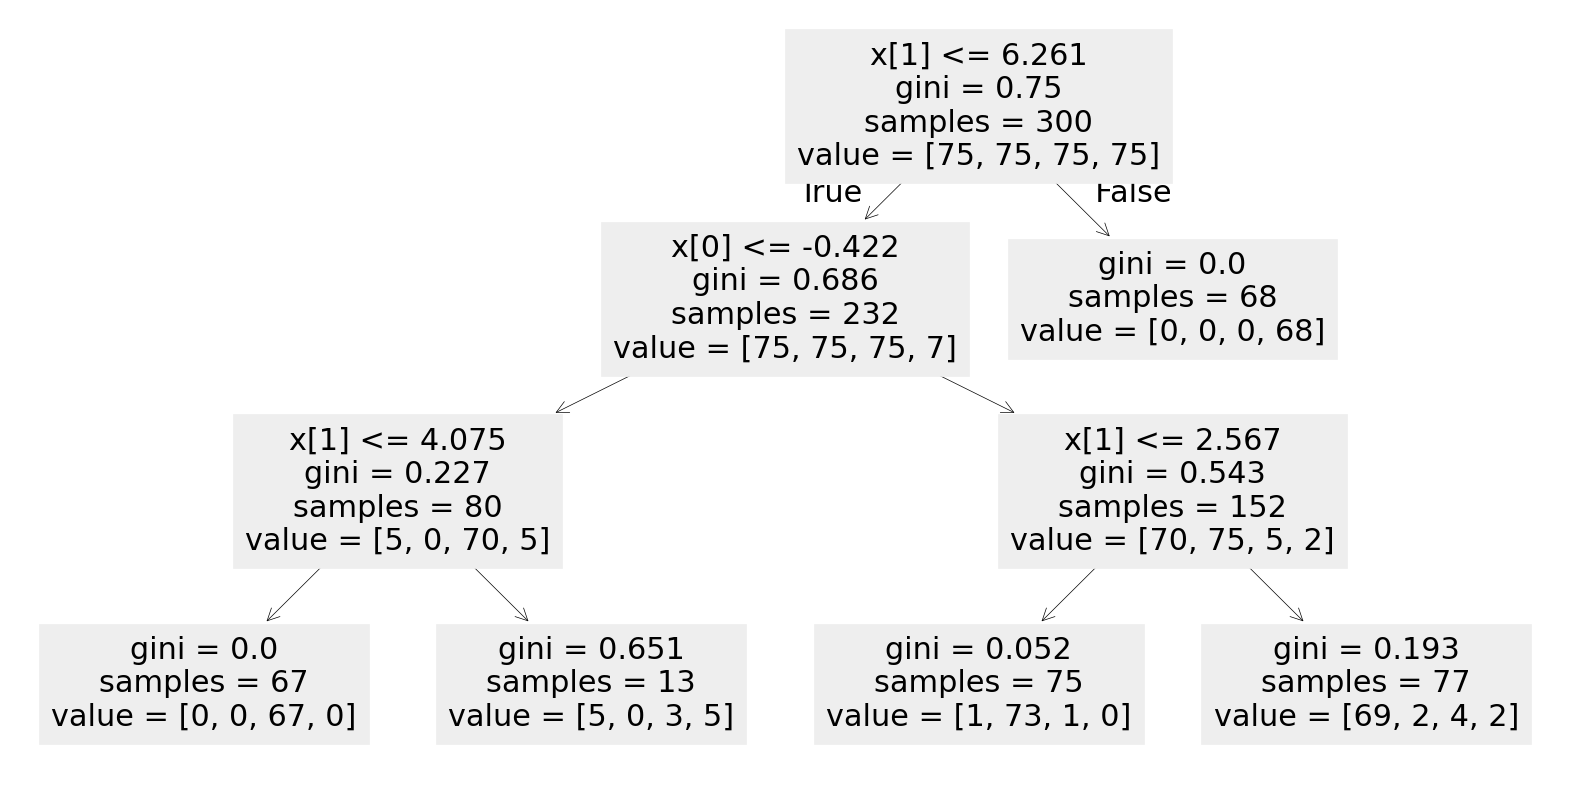

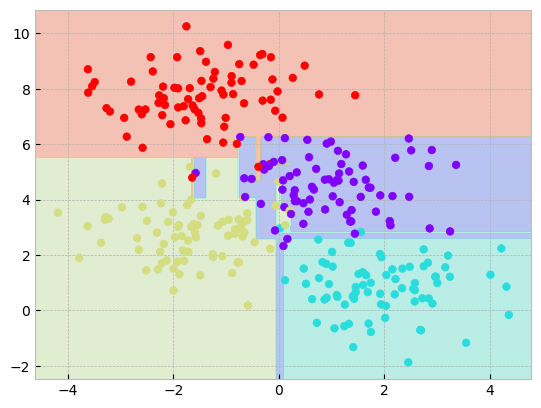

In [14]:
plt.figure(figsize=(20,10))
dt = DecisionTreeClassifier(max_depth=3,criterion='gini').fit(X,t)
plot_tree(dt);
plt.show()

visualize_classifier(DecisionTreeClassifier(), X, t);

## Estimating Class Probabilities

A Decision Tree can also estimate the probability that an instance belongs to a particular class $k$. First it traverses the tree to find the leaf node for this instance, and then it returns the ratio of training instances of class $k$ in this node.

In [15]:
X[:2]

array([[ 0.02458305,  2.96215652],
       [-1.52392631,  7.12573205]])

In [16]:
dt.predict_proba(X[:2])

array([[0.8961039 , 0.02597403, 0.05194805, 0.02597403],
       [0.        , 0.        , 0.        , 1.        ]])

## Decision Trees and Overfitting

Such overfitting turns out to be a general property of decision trees: it is very easy to go too deep in the tree, and thus to fit details of the particular data rather than the overall properties of the distributions they are drawn from. Another way to see this overfitting is to look at models trained on different subsets of the data — for example, in this figure we train two different trees, each on half of the original data:

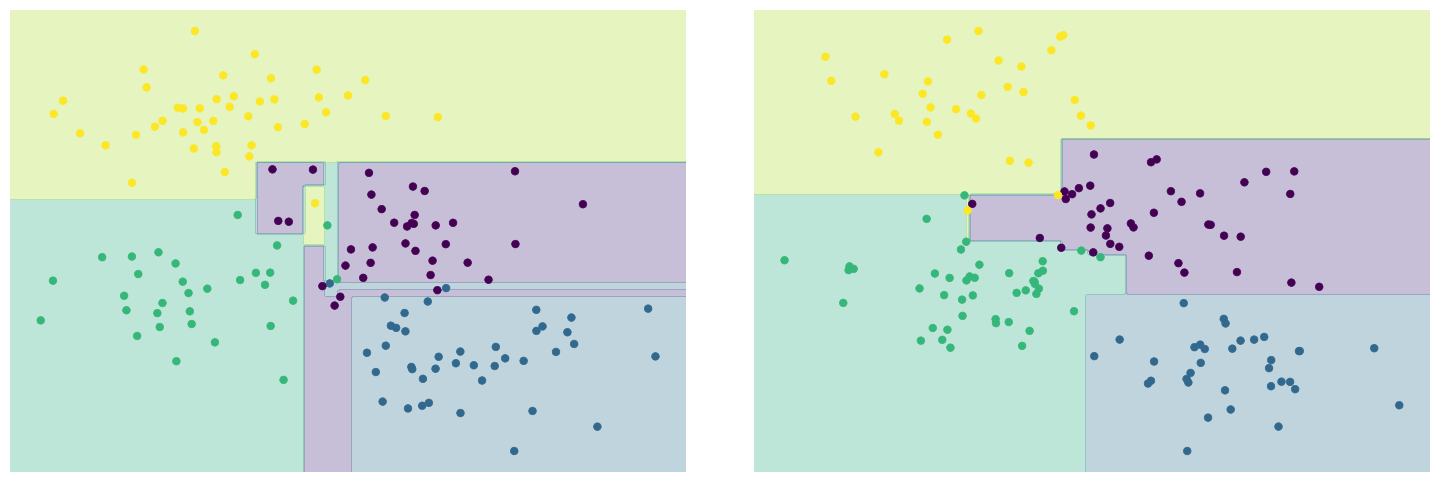

In [17]:
model = DecisionTreeClassifier()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
visualize_tree(model, X[::2], t[::2], boundaries=False, ax=ax[0])
visualize_tree(model, X[1::2], t[1::2], boundaries=False, ax=ax[1])

It is clear that in some places, the two trees produce consistent results, while in other places, the two trees give very different classifications (e.g., in the regions between any two clusters). The key observation is that the inconsistencies tend to happen where the classification is less certain, and thus by using information from both of these trees, we might come up with a better result!

Just as using information from two trees improves our results, we might expect that using information from many trees would improve our results even further.

## Regularization Hyperparameters

Decision trees make very few assumptions about the training data (as opposed to linear models, which assume that the data is linear, for example). If left unconstrained, the tree structure will adapt itself to the training data, fitting it very closely - indeed, most likely overfitting it. Such a model is often called a nonparametric model, not because it does not have any parameters (it often has a lot) but because the number of parameters is not determined prior to training, so the model structure is free to stick closely to the data. In contrast, a parametric model, such as a linear model, has a predetermined number of parameters, so its degree of freedom is limited, reducing the risk of overfitting (but increasing the risk of underfitting). 

To avoid overfitting the training data, you need to restrict the decision tree's freedom during training. As you know by now, this is called **regularization**. The regularization hyperparameters depend on the algorithm used, but generally you can at least restrict the **maximum depth** of the decision tree. In ```Scikit-Learn```, this is controlled by the ```max_depth``` hyperparameter (the default value is ```None```, which means unlimited). Reducing ```max_depth``` will regularize the model and thus reduce the risk of overfitting. 

The ```DecisionTreeClassifier``` class has a few other parameters that similarly restrict the shape of the decision tree: ```min_samples_split``` (the minimum number of samples a node must have before it can be split), ```min_samples_leaf``` (the minimum number of samples a leaf node must have), ```min_weight_fraction_leaf``` (same as ```min_samples_leaf``` but expressed as a fraction of the total number of weighted instances), ```max_leaf_nodes``` (the maximum number of leaf nodes), and ```max_features``` (the maximum number of features that are evaluated for splitting at each node). Increasing ```min_*``` hyperparameters or reducing ```max_*``` hyperparameters will regularize the model.

### Pruning the Tree

Other algorithms work by first training the decision tree without restrictions, then **pruning** (deleting) unnecessary nodes. A node whose children are all leaf nodes is considered unnecessary if the purity improvement it provides is not statistically significant. Standard statistical tests, such as the $\chi^2$ test (**chi-squared test**), are used to estimate the probability that the improvement is purely the result of chance (which is called the null hypothesis). If this probability, called the **p-value**, is higher than a given threshold (typically 5%, controlled by a hyperparameter), then the node is considered unnecessary and its children are deleted. The pruning continues until all unnecessary nodes have been pruned.

---